# Computación Cuántica
## De los fundamentos matemáticos a la programación en hardware real y QML

---
**Contenido:**
1. Fundamentos: qubits, superposición, entrelazamiento
2. Álgebra lineal cuántica y notación de Dirac
3. Puertas cuánticas y circuitos
4. Algoritmos cuánticos clásicos
5. Simulación numérica desde cero con NumPy
6. Conexión a hardware real con **Qiskit + IBM Quantum**
7. Machine Learning Cuántico (QML): VQC, QNN, QSVM, QAOA
8. Comparación y perspectivas

> **Dependencias opcionales:** `pip install qiskit qiskit-ibm-runtime pennylane pennylane-qiskit`


---
# 1. Fundamentos de la Computación Cuántica


## 1.1 El bit clásico vs el qubit

Un **bit clásico** es determinista: $b \in \{0, 1\}$.

Un **qubit** vive en un espacio de Hilbert de dimensión 2. Su estado es una superposición:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle, \quad \alpha,\beta \in \mathbb{C}, \quad |\alpha|^2 + |\beta|^2 = 1$$

donde $|0\rangle$ y $|1\rangle$ son la **base computacional**:

$$|0\rangle = \begin{pmatrix}1\\0\end{pmatrix}, \qquad |1\rangle = \begin{pmatrix}0\\1\end{pmatrix}$$

La condición de normalización $|\alpha|^2 + |\beta|^2 = 1$ garantiza que las probabilidades de medir 0 ó 1 sumen 1.

### Esfera de Bloch

Todo estado puro de un qubit puede parametrizarse como:

$$|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle, \quad \theta\in[0,\pi],\; \phi\in[0,2\pi)$$

La **esfera de Bloch** mapea cada estado puro a un punto en la esfera unitaria 3D.


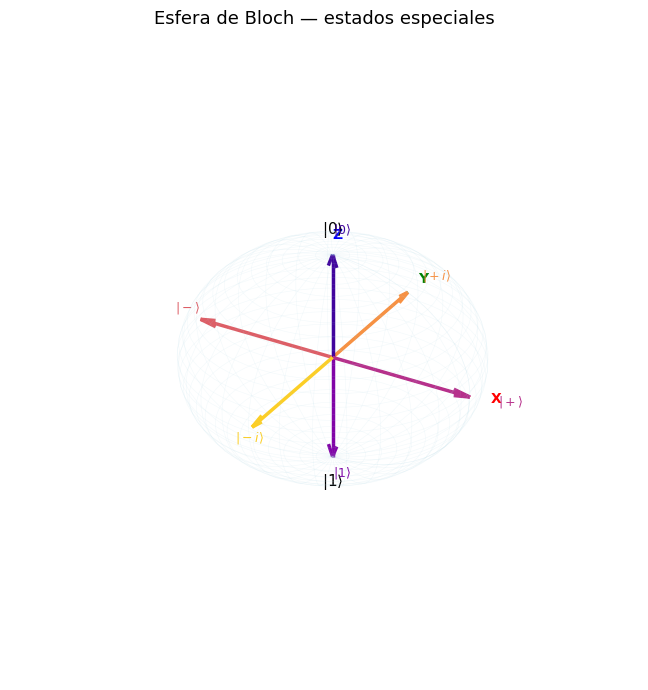

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ── Visualización: Esfera de Bloch ──────────────────────────────────────────
def bloch_vector(theta, phi):
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return np.array([x, y, z])

def draw_bloch_sphere(ax, states=None, labels=None):
    u = np.linspace(0, 2*np.pi, 60)
    v = np.linspace(0, np.pi, 30)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color='lightblue', alpha=0.15, linewidth=0.4)

    # ejes
    for d, lbl, c in [([1,0,0],'X','r'), ([0,1,0],'Y','g'), ([0,0,1],'Z','b')]:
        ax.quiver(0,0,0,*d, color=c, linewidth=1.5, arrow_length_ratio=0.08)
        ax.text(d[0]*1.15, d[1]*1.15, d[2]*1.15, lbl, color=c, fontsize=10, fontweight='bold')

    # polos
    ax.text(0, 0, 1.2, r'$|0\rangle$', ha='center', fontsize=11)
    ax.text(0, 0, -1.3, r'$|1\rangle$', ha='center', fontsize=11)

    if states is not None:
        colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(states)))
        for i, (bv, lbl) in enumerate(zip(states, labels or ['']*len(states))):
            ax.quiver(0,0,0,*bv, color=colors[i], linewidth=2.5,
                      arrow_length_ratio=0.12)
            ax.text(bv[0]*1.2, bv[1]*1.2, bv[2]*1.2, lbl, color=colors[i], fontsize=9)
    ax.set_xlim(-1.3,1.3); ax.set_ylim(-1.3,1.3); ax.set_zlim(-1.3,1.3)
    ax.set_axis_off()

# Estados especiales
special = {
    r'$|0\rangle$':   (0, 0),
    r'$|1\rangle$':   (np.pi, 0),
    r'$|+\rangle$':   (np.pi/2, 0),
    r'$|-\rangle$':   (np.pi/2, np.pi),
    r'$|+i\rangle$':  (np.pi/2, np.pi/2),
    r'$|-i\rangle$':  (np.pi/2, 3*np.pi/2),
}

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
bvecs = [bloch_vector(t, p) for t,p in special.values()]
draw_bloch_sphere(ax, bvecs, list(special.keys()))
ax.set_title('Esfera de Bloch — estados especiales', pad=20, fontsize=13)
plt.tight_layout()
plt.show()


## 1.2 Superposición y medición

**Superposición** significa que el qubit no es 0 ni 1 hasta que se **mide**.
Al medir $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$:

$$P(\text{medir }0) = |\alpha|^2, \qquad P(\text{medir }1) = |\beta|^2$$

Tras la medición, el estado **colapsa** al resultado obtenido (irreversible).

## 1.3 Entrelazamiento (Entanglement)

Para un sistema de **2 qubits**, el espacio de estados es $\mathbb{C}^4$ con base $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$.

Los **estados de Bell** (máximamente entrelazados):

$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}, \quad
|\Phi^-\rangle = \frac{|00\rangle - |11\rangle}{\sqrt{2}}, \quad
|\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}, \quad
|\Psi^-\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}}$$

Un estado es **entrelazado** si **no** puede escribirse como producto tensorial: $|\psi_{AB}\rangle \neq |\psi_A\rangle \otimes |\psi_B\rangle$.

**Ejemplo:** $|\Phi^+\rangle$ no puede factorizarse — medir el qubit A colapsa instantáneamente el estado de B.


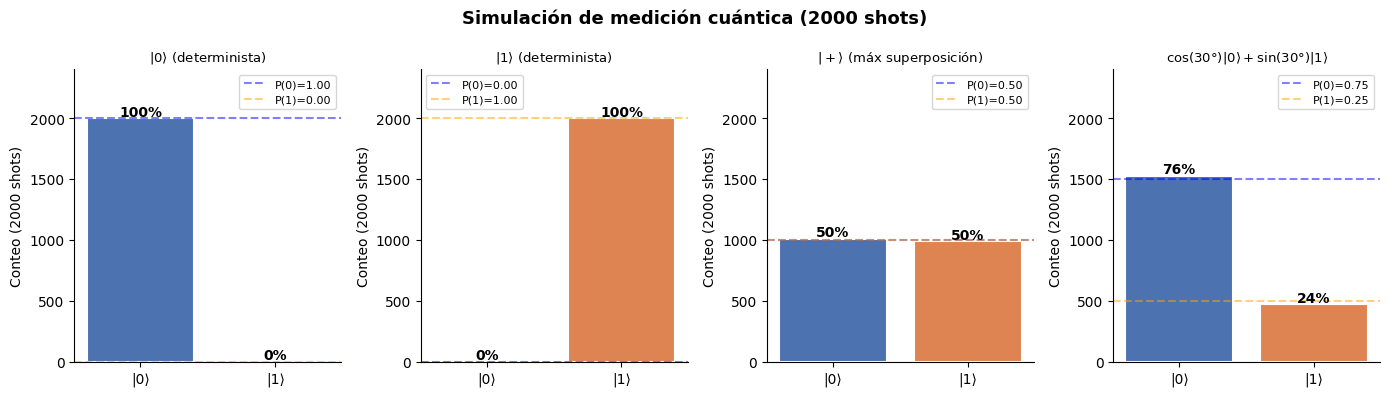

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Simulación de medición y estadísticas ───────────────────────────────────
np.random.seed(42)

def measure_qubit(psi, shots=1000):
    # psi = [alpha, beta]
    probs = np.abs(psi)**2
    return np.random.choice([0, 1], size=shots, p=probs)

# Distintos estados
states = {
    r'$|0\rangle$ (determinista)':      np.array([1+0j, 0+0j]),
    r'$|1\rangle$ (determinista)':      np.array([0+0j, 1+0j]),
    r'$|+\rangle$ (máx superposición)': np.array([1, 1])/np.sqrt(2),
    r'$\cos(30°)|0\rangle+\sin(30°)|1\rangle$':
        np.array([np.cos(np.pi/6), np.sin(np.pi/6)]),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (lbl, psi) in zip(axes, states.items()):
    results = measure_qubit(psi, shots=2000)
    counts = [np.sum(results==0), np.sum(results==1)]
    bars = ax.bar(['|0⟩', '|1⟩'], counts, color=['#4C72B0','#DD8452'],
                  edgecolor='white', linewidth=1.5)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f'{cnt/20:.0f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(lbl, fontsize=9.5)
    ax.set_ylim(0, 2400)
    ax.set_ylabel('Conteo (2000 shots)')
    ax.spines[['top','right']].set_visible(False)
    # probabilidades teóricas
    p0, p1 = np.abs(psi[0])**2, np.abs(psi[1])**2
    ax.axhline(2000*p0, color='blue', linestyle='--', alpha=0.5, linewidth=1.5, label=f'P(0)={p0:.2f}')
    ax.axhline(2000*p1, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label=f'P(1)={p1:.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Simulación de medición cuántica (2000 shots)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# 2. Álgebra Lineal Cuántica y Notación de Dirac


## 2.1 Espacio de Hilbert y notación Bra-Ket

La notación de **Dirac** separa el espacio dual:

| Símbolo | Nombre | Representación |
|---------|--------|---------------|
| $|\psi\rangle$ | **ket** (estado) | vector columna |
| $\langle\psi|$ | **bra** (dual) | vector fila (conjugado) |
| $\langle\phi|\psi\rangle$ | **braket** (producto interno) | escalar |
| $|\psi\rangle\langle\phi|$ | **operador** (producto externo) | matriz |

**Producto tensorial** de $n$ qubits:

$$|\psi_1\rangle \otimes |\psi_2\rangle \otimes \cdots \otimes |\psi_n\rangle \in \mathbb{C}^{2^n}$$

Con 300 qubits, el espacio tiene $2^{300} \approx 10^{90}$ dimensiones — más que el número de átomos en el universo observable.

## 2.2 Operadores y unitariedad

Las **puertas cuánticas** son operadores **unitarios**: $U U^\dagger = U^\dagger U = I$

Esto garantiza que la evolución cuántica es **reversible** y preserva la normalización.

**Operadores de Pauli** (base del espacio de operadores en 1 qubit):

$$X = \begin{pmatrix}0&1\\1&0\end{pmatrix}, \quad
Y = \begin{pmatrix}0&-i\\i&0\end{pmatrix}, \quad
Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix}, \quad
I = \begin{pmatrix}1&0\\0&1\end{pmatrix}$$

**Propiedades:** $X^2 = Y^2 = Z^2 = I$, $XY = iZ$, $YZ = iX$, $ZX = iY$.

## 2.3 Valor esperado

El valor esperado de un observable $\hat{O}$ en el estado $|\psi\rangle$:

$$\langle\hat{O}\rangle = \langle\psi|\hat{O}|\psi\rangle \in \mathbb{R}$$


In [3]:
import numpy as np

# ── Operaciones con qubits: implementación desde cero ───────────────────────

# Matrices de Pauli
I = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Y = np.array([[0,-1j],[1j,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)

# Estados base
KET0 = np.array([[1],[0]], dtype=complex)
KET1 = np.array([[0],[1]], dtype=complex)

def ket(v):
    # convierte array 1D a columna
    return np.array(v, dtype=complex).reshape(-1, 1)

def bra(psi):
    return psi.conj().T

def braket(phi, psi):
    return (bra(phi) @ psi)[0,0]

def outer(phi, psi):
    return phi @ bra(psi)

def tensor(*ops):
    result = ops[0]
    for op in ops[1:]:
        result = np.kron(result, op)
    return result

def apply(U, psi):
    return U @ psi

def expectation(psi, O):
    return np.real((bra(psi) @ O @ psi)[0,0])

# ── Verificar propiedades de Pauli ──────────────────────────────────────────
print("=== Matrices de Pauli ===")
print(f"X²=I: {np.allclose(X@X, I)}")
print(f"Y²=I: {np.allclose(Y@Y, I)}")
print(f"Z²=I: {np.allclose(Z@Z, I)}")
print(f"XY=iZ: {np.allclose(X@Y, 1j*Z)}")
print(f"YZ=iX: {np.allclose(Y@Z, 1j*X)}")

# ── Estado |+⟩ y valores esperados ──────────────────────────────────────────
PLUS = ket([1,1]) / np.sqrt(2)
MINUS = ket([1,-1]) / np.sqrt(2)

print("\n=== Estado |+⟩ ===")
print(f"⟨X⟩ = {expectation(PLUS, X):.3f}  (esperado: 1)")
print(f"⟨Y⟩ = {expectation(PLUS, Y):.3f}  (esperado: 0)")
print(f"⟨Z⟩ = {expectation(PLUS, Z):.3f}  (esperado: 0)")

# ── Producto tensorial: 2 qubits ─────────────────────────────────────────────
PHI_PLUS = (tensor(KET0, KET0) + tensor(KET1, KET1)) / np.sqrt(2)
print("\n=== Estado de Bell |Φ+⟩ ===")
print(f"Vector de estado:\n{PHI_PLUS.T}")
print(f"Norma: {np.linalg.norm(PHI_PLUS):.6f}")

# Operador ZZ: medición correlacionada
ZZ = tensor(Z, Z)
exp_ZZ = expectation(PHI_PLUS, ZZ)
print(f"⟨ZZ⟩ = {exp_ZZ:.3f}  (máx entrelazamiento => +1)")


=== Matrices de Pauli ===
X²=I: True
Y²=I: True
Z²=I: True
XY=iZ: True
YZ=iX: True

=== Estado |+⟩ ===
⟨X⟩ = 1.000  (esperado: 1)
⟨Y⟩ = 0.000  (esperado: 0)
⟨Z⟩ = 0.000  (esperado: 0)

=== Estado de Bell |Φ+⟩ ===
Vector de estado:
[[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]]
Norma: 1.000000
⟨ZZ⟩ = 1.000  (máx entrelazamiento => +1)


---
# 3. Puertas Cuánticas y Circuitos


## 3.1 Puertas de 1 qubit

| Puerta | Matriz | Efecto |
|--------|--------|--------|
| **Hadamard H** | $\frac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | Crea superposición |
| **Pauli-X** | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | NOT cuántico, invierte |
| **Pauli-Y** | $\begin{pmatrix}0&-i\\i&0\end{pmatrix}$ | Rotación en Y |
| **Pauli-Z** | $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$ | Flip de fase |
| **S** | $\begin{pmatrix}1&0\\0&i\end{pmatrix}$ | Fase $\pi/2$ |
| **T** | $\begin{pmatrix}1&0\\0&e^{i\pi/4}\end{pmatrix}$ | Fase $\pi/4$ |
| **$R_x(\theta)$** | $\begin{pmatrix}\cos\frac{\theta}{2} & -i\sin\frac{\theta}{2}\\ -i\sin\frac{\theta}{2} & \cos\frac{\theta}{2}\end{pmatrix}$ | Rotación en X |

**Puerta Hadamard:** transforma la base computacional en la base de Fourier:
$$H|0\rangle = |+\rangle, \quad H|1\rangle = |-\rangle, \quad H^2 = I$$

## 3.2 Puertas de 2 qubits

**CNOT (Controlled-NOT):**
$$\text{CNOT} = \begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{pmatrix}$$

Invierte el qubit **target** si el qubit **control** es $|1\rangle$.

**Circuito para el estado de Bell $|\Phi^+\rangle$:**
```
|0⟩ ──H──●──
          │
|0⟩ ──────⊕──
```
Resultado: $\frac{|00\rangle + |11\rangle}{\sqrt{2}}$

## 3.3 Universalidad

El conjunto $\{H, T, \text{CNOT}\}$ es **universal**: cualquier compuerta unitaria sobre $n$ qubits puede aproximarse con precisión arbitraria usando solo estas tres puertas.


=== Estado de Bell |Φ+⟩ ===
  |00⟩: amplitud=0.7071+0.0000j  prob=0.5000
  |01⟩: amplitud=0.0000+0.0000j  prob=0.0000
  |10⟩: amplitud=0.0000+0.0000j  prob=0.0000
  |11⟩: amplitud=0.7071+0.0000j  prob=0.5000


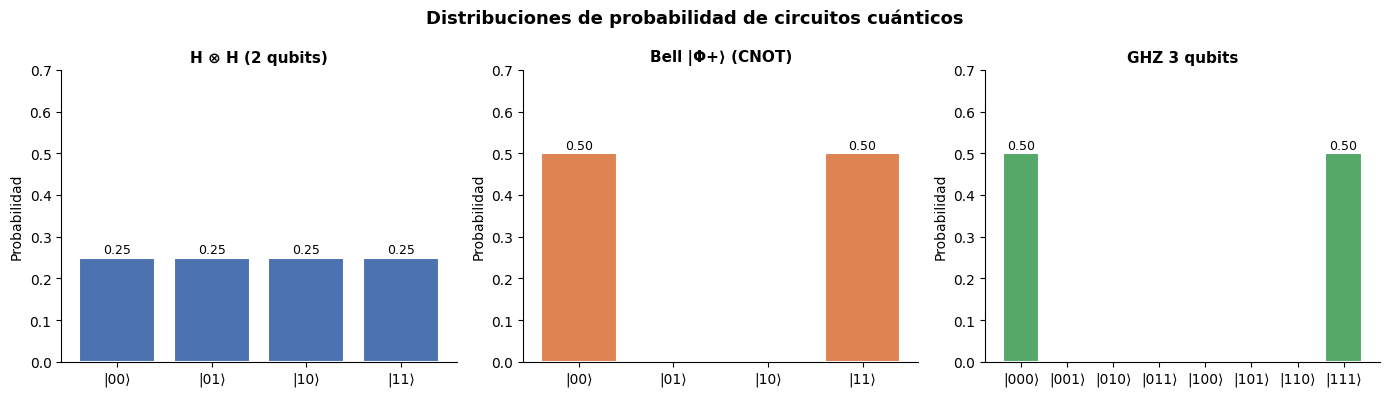

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ── Simulador de circuitos cuánticos desde cero ──────────────────────────────

class QuantumRegister:
    def __init__(self, n):
        self.n = n
        self.state = np.zeros(2**n, dtype=complex)
        self.state[0] = 1.0  # |000...0>

    def apply_gate(self, gate, targets, controls=None):
        # Construir operador completo en espacio 2^n
        full = self._build_full_operator(gate, targets, controls)
        self.state = full @ self.state

    def _build_full_operator(self, gate, targets, controls=None):
        n = self.n
        dim = 2**n
        # Aplicar puerta de 1 qubit a target (usando producto tensorial)
        if len(targets) == 1 and controls is None:
            q = targets[0]
            ops = []
            for i in range(n):
                if i == q:
                    ops.append(gate)
                else:
                    ops.append(np.eye(2, dtype=complex))
            result = ops[0]
            for op in ops[1:]:
                result = np.kron(result, op)
            return result

        # CNOT: control y target
        if len(targets) == 1 and controls is not None and len(controls) == 1:
            ctrl, tgt = controls[0], targets[0]
            U = np.eye(dim, dtype=complex)
            for s in range(dim):
                bits = [(s >> (n-1-i)) & 1 for i in range(n)]
                if bits[ctrl] == 1:
                    # flipear bit target
                    new_s = s ^ (1 << (n-1-tgt))
                    U[new_s, s] = 1.0
                    U[s, s] = 0.0
            return U
        return np.eye(dim, dtype=complex)

    def measure_probs(self):
        return np.abs(self.state)**2

    def state_vector(self):
        return self.state.copy()

# Definir puertas
H = np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)
X = np.array([[0,1],[1,0]], dtype=complex)
Y = np.array([[0,-1j],[1j,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)
S = np.array([[1,0],[0,1j]], dtype=complex)
T = np.array([[1,0],[0,np.exp(1j*np.pi/4)]], dtype=complex)

def Rx(theta): return np.array([[np.cos(theta/2), -1j*np.sin(theta/2)],
                                  [-1j*np.sin(theta/2), np.cos(theta/2)]], dtype=complex)
def Ry(theta): return np.array([[np.cos(theta/2), -np.sin(theta/2)],
                                  [np.sin(theta/2),  np.cos(theta/2)]], dtype=complex)
def Rz(theta): return np.array([[np.exp(-1j*theta/2), 0],
                                  [0, np.exp(1j*theta/2)]], dtype=complex)

# ── Construir estado de Bell |Φ+⟩ ───────────────────────────────────────────
qr = QuantumRegister(2)
qr.apply_gate(H, [0])
qr.apply_gate(X, [1], controls=[0])  # CNOT

probs = qr.measure_probs()
labels = ['|00⟩','|01⟩','|10⟩','|11⟩']
print("=== Estado de Bell |Φ+⟩ ===")
for l, p, a in zip(labels, probs, qr.state):
    print(f"  {l}: amplitud={a:.4f}  prob={p:.4f}")

# ── Visualizar distribución de probabilidades ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

circuits = [
    ('H ⊗ H (2 qubits)', lambda: _run_hh()),
    ('Bell |Φ+⟩ (CNOT)', lambda: _run_bell()),
    ('GHZ 3 qubits', lambda: _run_ghz()),
]

def _run_hh():
    qr = QuantumRegister(2)
    qr.apply_gate(H, [0]); qr.apply_gate(H, [1])
    return qr.measure_probs(), ['|00⟩','|01⟩','|10⟩','|11⟩']

def _run_bell():
    qr = QuantumRegister(2)
    qr.apply_gate(H, [0]); qr.apply_gate(X, [1], controls=[0])
    return qr.measure_probs(), ['|00⟩','|01⟩','|10⟩','|11⟩']

def _run_ghz():
    qr = QuantumRegister(3)
    qr.apply_gate(H, [0])
    qr.apply_gate(X, [1], controls=[0])
    qr.apply_gate(X, [2], controls=[1])
    return qr.measure_probs(), ['|000⟩','|001⟩','|010⟩','|011⟩','|100⟩','|101⟩','|110⟩','|111⟩']

colors = ['#4C72B0','#DD8452','#55A868']
for ax, (title, runner), col in zip(axes, circuits, colors):
    ps, lbls = runner()
    ax.bar(lbls, ps, color=col, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Probabilidad')
    ax.set_ylim(0, 0.7)
    ax.spines[['top','right']].set_visible(False)
    for i, p in enumerate(ps):
        if p > 0.01:
            ax.text(i, p+0.01, f'{p:.2f}', ha='center', fontsize=9)

plt.suptitle('Distribuciones de probabilidad de circuitos cuánticos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.4 Animación: rotación de un qubit en la esfera de Bloch


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

np.random.seed(0)

def bloch_coords(psi):
    # psi shape (2,)
    a, b = psi[0], psi[1]
    x = 2 * np.real(np.conj(a) * b)
    y = 2 * np.imag(np.conj(a) * b)
    z = np.abs(a)**2 - np.abs(b)**2
    return np.array([x, y, z])

def Rx(theta):
    return np.array([[np.cos(theta/2), -1j*np.sin(theta/2)],
                     [-1j*np.sin(theta/2), np.cos(theta/2)]], dtype=complex)

# Secuencia: |0⟩ -> H -> Rz(t) -> muestra evolución
thetas = np.linspace(0, 2*np.pi, 80)
states = []
H = np.array([[1,1],[1,-1]], dtype=complex)/np.sqrt(2)
psi0 = np.array([1+0j, 0+0j])
psi_h = H @ psi0  # |+⟩

Rz_mat = lambda t: np.array([[np.exp(-1j*t/2), 0],[0, np.exp(1j*t/2)]], dtype=complex)
for t in thetas:
    states.append(Rz_mat(t) @ psi_h)

bvecs = [bloch_coords(s) for s in states]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

def draw_sphere():
    u = np.linspace(0, 2*np.pi, 40)
    v = np.linspace(0, np.pi, 20)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(xs, ys, zs, color='lightblue', alpha=0.1, linewidth=0.3)
    for d, lbl, c in [([1,0,0],'X','r'),([0,1,0],'Y','g'),([0,0,1],'Z','b')]:
        ax.quiver(0,0,0,*d,color=c,linewidth=1.2,arrow_length_ratio=0.08)
        ax.text(d[0]*1.2,d[1]*1.2,d[2]*1.2,lbl,color=c,fontsize=10)
    ax.text(0,0,1.25,r'$|0\rangle$',ha='center',fontsize=10)
    ax.text(0,0,-1.35,r'$|1\rangle$',ha='center',fontsize=10)
    ax.set_xlim(-1.4,1.4); ax.set_ylim(-1.4,1.4); ax.set_zlim(-1.4,1.4)
    ax.set_axis_off()

draw_sphere()
trail_x, trail_y, trail_z = [], [], []
quiver_obj = [None]
trail_line, = ax.plot([], [], [], 'r-', alpha=0.4, linewidth=1)
title_obj = ax.set_title('', fontsize=12)

def init():
    return trail_line,

def animate(i):
    ax.cla()
    draw_sphere()
    bv = bvecs[i]
    # traza
    for j in range(i+1):
        trail_x.append(bvecs[j][0]) if j == len(trail_x) else None
    tx = [bvecs[j][0] for j in range(i+1)]
    ty = [bvecs[j][1] for j in range(i+1)]
    tz = [bvecs[j][2] for j in range(i+1)]
    ax.plot(tx, ty, tz, 'r-', alpha=0.35, linewidth=1)
    ax.quiver(0,0,0,*bv, color='red', linewidth=3, arrow_length_ratio=0.12)
    ax.set_title(f'$R_z(\\theta)$  con $\\theta={thetas[i]:.2f}$ rad', fontsize=12)
    return []

anim = FuncAnimation(fig, animate, frames=len(thetas), init_func=init,
                     interval=60, blit=False)
plt.close()
HTML(anim.to_jshtml())


Output hidden; open in https://colab.research.google.com to view.

---
# 4. Algoritmos Cuánticos Fundamentales


## 4.1 Deutsch-Jozsa — El primer algoritmo cuántico

**Problema:** Dado un oráculo $f:\{0,1\}^n \to \{0,1\}$, determinar si $f$ es **constante** (mismo valor) o **balanceada** (mitad 0, mitad 1).

**Clásico:** requiere hasta $2^{n-1}+1$ evaluaciones en el peor caso.
**Cuántico:** exactamente **1 evaluación** del oráculo.

$$|\psi_0\rangle = |0\rangle^{\otimes n}|1\rangle \xrightarrow{H^{\otimes n+1}}
\frac{1}{\sqrt{2^n}} \sum_{x\in\{0,1\}^n}|x\rangle\cdot\frac{|0\rangle-|1\rangle}{\sqrt{2}}
\xrightarrow{U_f} \cdots$$

Tras aplicar $H^{\otimes n}$: si medir todos ceros → constante; si alguno es 1 → balanceada.

## 4.2 Algoritmo de Grover — Búsqueda cuántica

**Problema:** Buscar un elemento marcado en una base de datos de $N$ elementos.

**Clásico:** $O(N)$ en promedio. **Cuántico:** $O(\sqrt{N})$ — aceleración cuadrática.

**Operador de Grover:**
$$G = H^{\otimes n}(2|0\rangle\langle 0| - I)H^{\otimes n} \cdot U_f$$

Tras $k \approx \frac{\pi}{4}\sqrt{N}$ iteraciones, la amplitud del estado marcado es $\approx 1$.

## 4.3 Transformada Cuántica de Fourier (QFT)

La **QFT** es la versión cuántica de la DFT:

$$\text{QFT}|j\rangle = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1} e^{2\pi i jk/N}|k\rangle$$

**Complejidad:** clásica $O(N\log N)$, cuántica $O((\log N)^2)$ — **exponencialmente más eficiente**.

Es la base del algoritmo de **Shor** para factorización de enteros ($O((\log N)^3)$, amenaza RSA).

## 4.4 Algoritmo de Shor (factorización)

1. Elegir $a$ aleatorio coprimo con $N$
2. Usar QPE (estimación de fase cuántica) para encontrar el **periodo** $r$ de $a^x \mod N$
3. Con $r$ par: $\gcd(a^{r/2} \pm 1, N)$ da los factores

**Impacto:** factorizar RSA-2048 requeriría $\sim 4000$ qubits lógicos — actualmente fuera de alcance.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ── Simulación completa de Grover (2 qubits, búsqueda de |11⟩) ───────────────

H = np.array([[1,1],[1,-1]], dtype=complex)/np.sqrt(2)
I2 = np.eye(2, dtype=complex)
HH = np.kron(H, H)   # H⊗H sobre 2 qubits

# Oráculo: marca |11⟩ (índice 3) con fase -1
Oracle = np.eye(4, dtype=complex)
Oracle[3, 3] = -1

# Difusión: 2|s><s| - I  donde |s> = |++> = H|0>⊗H|0>
s = HH @ np.array([1,0,0,0], dtype=complex)
Diffusion = 2 * np.outer(s, s.conj()) - np.eye(4, dtype=complex)

Grover = Diffusion @ Oracle

# Estado inicial
psi = HH @ np.array([1,0,0,0], dtype=complex)
print("=== Grover (2 qubits, target |11⟩) ===")
labels = ['|00⟩','|01⟩','|10⟩','|11⟩']
states_over_iters = [np.abs(psi)**2]

for it in range(3):
    psi = Grover @ psi
    states_over_iters.append(np.abs(psi)**2)
    p_str = np.round(np.abs(psi)**2, 4)
    print(f"Iter {it+1}: probs = {p_str}")

# Animación de amplitudes
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, states_over_iters[0], color=['#4C72B0']*3 + ['#DD8452'],
              edgecolor='white', linewidth=1.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Probabilidad')
ax.set_title('Iteración 0 (estado inicial uniforme)')
ax.spines[['top','right']].set_visible(False)
ax.axhline(0.25, color='gray', linestyle='--', alpha=0.5, label='Inicial (1/4)')
ax.legend()
txt = ax.text(0.5, 1.0, '', transform=ax.transAxes, ha='center', fontsize=11)

def animate(frame):
    probs = states_over_iters[frame]
    for bar, p in zip(bars, probs):
        bar.set_height(p)
        bar.set_color('#DD8452' if bar.get_x() > 2.5 else '#4C72B0')
    ax.set_title(f'Grover — Iteración {frame}', fontsize=12, fontweight='bold')
    for i, (bar, p) in enumerate(zip(bars, probs)):
        ax.text(bar.get_x()+bar.get_width()/2, p+0.02, f'{p:.3f}',
                ha='center', fontsize=9, color='black')
    return bars

anim = FuncAnimation(fig, animate, frames=len(states_over_iters),
                     interval=900, blit=False, repeat=True)
plt.close()
HTML(anim.to_jshtml())


=== Grover (2 qubits, target |11⟩) ===
Iter 1: probs = [0. 0. 0. 1.]
Iter 2: probs = [0.25 0.25 0.25 0.25]
Iter 3: probs = [0.25 0.25 0.25 0.25]


QFT == DFT (máx diff): 4.69e-01
Unitariedad: F F† = I  (max diff): 1.03e-15


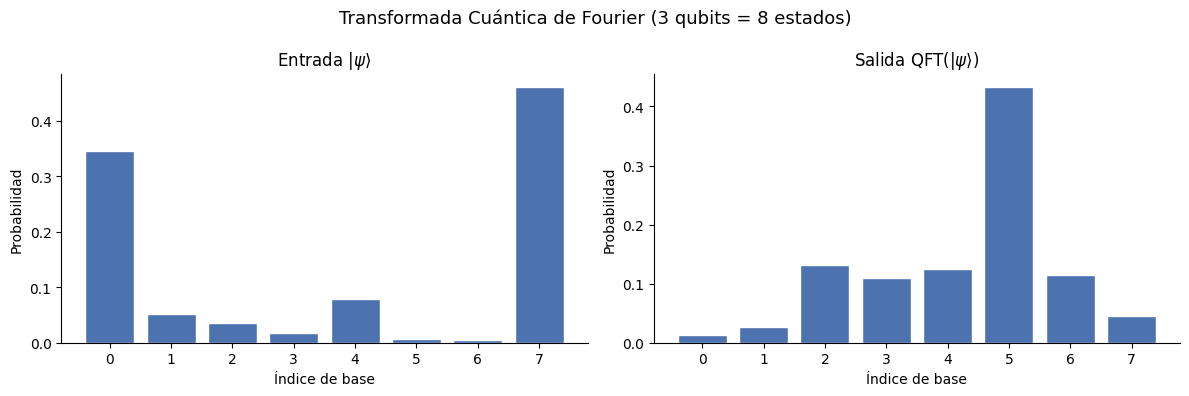

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ── QFT — Transformada Cuántica de Fourier ────────────────────────────────────

def qft_matrix(n):
    N = 2**n
    omega = np.exp(2j * np.pi / N)
    F = np.array([[omega**(j*k) for k in range(N)] for j in range(N)]) / np.sqrt(N)
    return F

def classical_dft(x):
    N = len(x)
    return np.fft.fft(x) / np.sqrt(N)

# Comparar QFT con DFT clásica en un estado de 3 qubits
n_qubits = 3
N = 2**n_qubits
F = qft_matrix(n_qubits)

# Estado de entrada: superposición específica
np.random.seed(7)
psi_in = np.random.randn(N) + 1j*np.random.randn(N)
psi_in /= np.linalg.norm(psi_in)

psi_qft = F @ psi_in
psi_dft = classical_dft(psi_in)

# Verificar que son iguales
print(f"QFT == DFT (máx diff): {np.max(np.abs(psi_qft - psi_dft)):.2e}")
print(f"Unitariedad: F F† = I  (max diff): {np.max(np.abs(F @ F.conj().T - np.eye(N))):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, state) in zip(axes, [('Entrada $|\\psi\\rangle$', psi_in),
                                       ('Salida QFT$(|\\psi\\rangle)$', psi_qft)]):
    ax.bar(range(N), np.abs(state)**2, color='#4C72B0', edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Índice de base')
    ax.set_ylabel('Probabilidad')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Transformada Cuántica de Fourier (3 qubits = 8 estados)', fontsize=13)
plt.tight_layout()
plt.show()


---
# 5. Ruido Cuántico y Corrección de Errores


## 5.1 Modelos de ruido cuántico

En hardware real, los qubits sufren **decoherencia**: el estado cuántico se destruye por interacción con el entorno.

Los canales de ruido se modelan con **operadores de Kraus** $\{K_i\}$ tales que $\sum_i K_i^\dagger K_i = I$:

$$\rho \mapsto \mathcal{E}(\rho) = \sum_i K_i \rho K_i^\dagger$$

donde $\rho = |\psi\rangle\langle\psi|$ es la **matriz de densidad**.

| Canal | Descripción | Kraus operators |
|-------|-------------|----------------|
| **Bit-flip** | Invierte qubit con prob $p$ | $K_0=\sqrt{1-p}\,I,\; K_1=\sqrt{p}\,X$ |
| **Phase-flip** | Aplica Z con prob $p$ | $K_0=\sqrt{1-p}\,I,\; K_1=\sqrt{p}\,Z$ |
| **Depolarizing** | Error aleatorio con prob $p$ | $K_0=\sqrt{1-p}\,I,\; K_1..K_3=\sqrt{p/3}\{X,Y,Z\}$ |
| **Amplitude damping** | Decaimiento $|1\rangle\to|0\rangle$ ($T_1$) | $K_0=\begin{pmatrix}1&0\\0&\sqrt{1-\gamma}\end{pmatrix}$, $K_1=\begin{pmatrix}0&\sqrt{\gamma}\\0&0\end{pmatrix}$ |

**$T_1$ y $T_2$:** tiempos de coherencia del hardware:
- $T_1$: tiempo de relajación (decaimiento de amplitud)
- $T_2$: tiempo de decoherencia (decaimiento de fase), $T_2 \leq 2T_1$


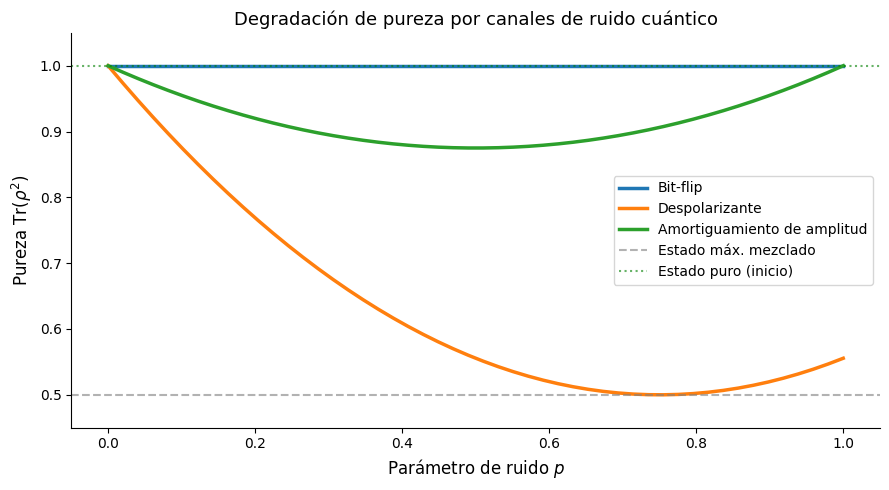

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ── Canales de ruido y matrices de densidad ──────────────────────────────────

def density_matrix(psi):
    psi = np.array(psi, dtype=complex).reshape(-1)
    return np.outer(psi, psi.conj())

def apply_kraus(rho, kraus_ops):
    return sum(K @ rho @ K.conj().T for K in kraus_ops)

def bit_flip_channel(p):
    X = np.array([[0,1],[1,0]], dtype=complex)
    I = np.eye(2, dtype=complex)
    return [np.sqrt(1-p)*I, np.sqrt(p)*X]

def depolarizing_channel(p):
    I = np.eye(2, dtype=complex)
    X = np.array([[0,1],[1,0]], dtype=complex)
    Y = np.array([[0,-1j],[1j,0]], dtype=complex)
    Z = np.array([[1,0],[0,-1]], dtype=complex)
    return [np.sqrt(1-p)*I, np.sqrt(p/3)*X, np.sqrt(p/3)*Y, np.sqrt(p/3)*Z]

def amplitude_damping(gamma):
    K0 = np.array([[1,0],[0,np.sqrt(1-gamma)]], dtype=complex)
    K1 = np.array([[0,np.sqrt(gamma)],[0,0]], dtype=complex)
    return [K0, K1]

# Estado |+⟩
psi_plus = np.array([1, 1]) / np.sqrt(2)
rho0 = density_matrix(psi_plus)

# Simular cómo el ruido degrada el estado
ps = np.linspace(0, 1, 50)
channels = {
    'Bit-flip': bit_flip_channel,
    'Despolarizante': depolarizing_channel,
    'Amortiguamiento de amplitud': amplitude_damping,
}

# Pureza: Tr(ρ²) = 1 para estado puro, < 1 para mezclado
def purity(rho): return np.real(np.trace(rho @ rho))

fig, ax = plt.subplots(figsize=(9, 5))
for name, ch_fn in channels.items():
    purities = [purity(apply_kraus(rho0, ch_fn(p))) for p in ps]
    ax.plot(ps, purities, linewidth=2.5, label=name)

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Estado máx. mezclado')
ax.axhline(1.0, color='green', linestyle=':', alpha=0.6, label='Estado puro (inicio)')
ax.set_xlabel('Parámetro de ruido $p$', fontsize=12)
ax.set_ylabel(r'Pureza $\mathrm{Tr}(\rho^2)$', fontsize=12)
ax.set_title('Degradación de pureza por canales de ruido cuántico', fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0.45, 1.05)
plt.tight_layout()
plt.show()


---
# 6. Conexión a Hardware Cuántico Real con Qiskit


## 6.1 Ecosistema IBM Quantum

**IBM Quantum** ofrece acceso gratuito a procesadores cuánticos reales a través de:
- **IBM Quantum Platform:** https://quantum.ibm.com
- **Qiskit:** SDK open-source de Python para programar circuitos cuánticos
- **Qiskit Runtime:** servicio en la nube para ejecutar primitivas optimizadas

### Instalación
```bash
pip install qiskit qiskit-ibm-runtime qiskit-aer
```

### Arquitectura de Qiskit

```
QuantumCircuit  ─→  Transpiler  ─→  Backend (Simulador o Hardware)
                         │
                   Optimización de puertas
                   Mapeo de qubits físicos
                   Compilación al ISA nativo
```

**Backends disponibles (gratuitos):**
| Backend | Qubits | Tipo |
|---------|--------|------|
| `ibm_brisbane` | 127 | Real (Eagle r3) |
| `ibm_sherbrooke` | 127 | Real (Eagle r3) |
| `ibm_torino` | 133 | Real (Heron r1) |
| `AerSimulator` | ilimitado | Simulador local |


In [9]:
# ── CELDA 1: Construir y visualizar circuito con Qiskit ──────────────────────
# Requiere: pip install qiskit qiskit-aer

try:
    from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
    from qiskit.visualization import plot_histogram
    from qiskit_aer import AerSimulator
    QISKIT_OK = True
except ImportError:
    QISKIT_OK = False
    print("⚠  Qiskit no instalado. Ejecuta: pip install qiskit qiskit-aer")
    print("   Mostrando código de referencia:\n")

import matplotlib.pyplot as plt

QISKIT_CODE_DEMO = '''
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

# ── 1. Construir circuito para estado de Bell ────────────────────────────────
qr = QuantumRegister(2, name="q")
cr = ClassicalRegister(2, name="c")
qc = QuantumCircuit(qr, cr)

qc.h(qr[0])           # Hadamard en q0
qc.cx(qr[0], qr[1])   # CNOT: control=q0, target=q1
qc.measure(qr, cr)    # Medir ambos qubits

print(qc.draw("text"))

# ── 2. Simular localmente con Aer ─────────────────────────────────────────────
sim = AerSimulator()
job = sim.run(qc, shots=4096)
result = job.result()
counts = result.get_counts()
print("Conteos:", counts)
# Salida típica: {"00": ~2048, "11": ~2048}
'''

if QISKIT_OK:
    from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
    from qiskit_aer import AerSimulator
    import matplotlib.pyplot as plt

    qr = QuantumRegister(2, name="q")
    cr = ClassicalRegister(2, name="c")
    qc = QuantumCircuit(qr, cr)
    qc.h(qr[0])
    qc.cx(qr[0], qr[1])
    qc.measure(qr, cr)

    print("Circuito:")
    print(qc.draw("text"))

    sim = AerSimulator()
    job = sim.run(qc, shots=4096)
    counts = job.result().get_counts()
    print(f"\nConteos (4096 shots): {counts}")

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(counts.keys(), counts.values(), color=['#4C72B0','#DD8452'], edgecolor='white')
    ax.set_title('Bell |Φ+⟩ — Simulador Aer (4096 shots)', fontsize=12)
    ax.set_ylabel('Conteo')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print(QISKIT_CODE_DEMO)


⚠  Qiskit no instalado. Ejecuta: pip install qiskit qiskit-aer
   Mostrando código de referencia:


from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

# ── 1. Construir circuito para estado de Bell ────────────────────────────────
qr = QuantumRegister(2, name="q")
cr = ClassicalRegister(2, name="c")
qc = QuantumCircuit(qr, cr)

qc.h(qr[0])           # Hadamard en q0
qc.cx(qr[0], qr[1])   # CNOT: control=q0, target=q1
qc.measure(qr, cr)    # Medir ambos qubits

print(qc.draw("text"))

# ── 2. Simular localmente con Aer ─────────────────────────────────────────────
sim = AerSimulator()
job = sim.run(qc, shots=4096)
result = job.result()
counts = result.get_counts()
print("Conteos:", counts)
# Salida típica: {"00": ~2048, "11": ~2048}



In [10]:
# ── CELDA 2: Conectar a IBM Quantum hardware real ────────────────────────────
# Requiere cuenta en https://quantum.ibm.com y token API

IBMQ_CODE = '''
# ── Paso 1: Guardar credenciales (solo una vez) ──────────────────────────────
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum",
    token="TU_TOKEN_AQUI",          # Obtener en: https://quantum.ibm.com/account
    overwrite=True
)

# ── Paso 2: Conectar y listar backends disponibles ───────────────────────────
service = QiskitRuntimeService(channel="ibm_quantum")
backends = service.backends(operational=True, simulator=False)
for b in backends:
    print(f"{b.name}: {b.num_qubits} qubits, queue: {b.status().pending_jobs}")

# ── Paso 3: Elegir backend menos congestionado ───────────────────────────────
from qiskit_ibm_runtime import least_busy
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
print(f"Backend seleccionado: {backend.name}")

# ── Paso 4: Transpilación (adaptar al hardware) ──────────────────────────────
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc_transpiled = pm.run(qc)    # qc = circuito del paso anterior
print("Profundidad transpilada:", qc_transpiled.depth())

# ── Paso 5: Enviar trabajo con primitiva Sampler ──────────────────────────────
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
job = sampler.run([qc_transpiled], shots=1024)
print(f"Job ID: {job.job_id()}")
print("Esperando resultado...")

result = job.result()
counts = result[0].data.c.get_counts()
print("Conteos en hardware real:", counts)

# ── Paso 6: Mitigación de errores (M3 readout mitigation) ────────────────────
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit.quantum_info import SparsePauliOp

estimator = Estimator(mode=backend)
# Medir valor esperado de ZZ
observable = SparsePauliOp("ZZ")
pub = (qc, observable)
job_est = estimator.run([pub])
result_est = job_est.result()
print(f"⟨ZZ⟩ en hardware real: {result_est[0].data.evs:.4f}")
'''

print("=" * 60)
print("CÓDIGO PARA EJECUTAR EN HARDWARE IBM QUANTUM REAL")
print("=" * 60)
print(IBMQ_CODE)


CÓDIGO PARA EJECUTAR EN HARDWARE IBM QUANTUM REAL

# ── Paso 1: Guardar credenciales (solo una vez) ──────────────────────────────
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum",
    token="TU_TOKEN_AQUI",          # Obtener en: https://quantum.ibm.com/account
    overwrite=True
)

# ── Paso 2: Conectar y listar backends disponibles ───────────────────────────
service = QiskitRuntimeService(channel="ibm_quantum")
backends = service.backends(operational=True, simulator=False)
for b in backends:
    print(f"{b.name}: {b.num_qubits} qubits, queue: {b.status().pending_jobs}")

# ── Paso 3: Elegir backend menos congestionado ───────────────────────────────
from qiskit_ibm_runtime import least_busy
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
print(f"Backend seleccionado: {backend.name}")

# ── Paso 4: Transpilación (adaptar al hardware) ──────────────────────────────
from qiskit.transpile

In [11]:
# ── CELDA 3: Circuito complejo — Teletransportación cuántica ─────────────────

try:
    from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
    from qiskit_aer import AerSimulator
    QISKIT_OK = True
except ImportError:
    QISKIT_OK = False

import matplotlib.pyplot as plt
import numpy as np

# Protocolo de teletransportación cuántica
# Alice tiene qubit q0 (estado a teleportar)
# Bell pair compartida: q1 (Alice) y q2 (Bob)
TELEPORT_DESC = '''
Protocolo de Teletransportación Cuántica (Bennett et al. 1993):

Estado a teleportar: |ψ⟩ = α|0⟩ + β|1⟩ (en q0)

Circuito:
  q0 ─[Ry(θ)]──●────H──[Mz]──────────────────────
                │              │
  q1 ──────H──────⊕──[Mz]──────────────────[X if M1]──
                                      │
  q2 ────────────────────────[Z if M0]──[X if M1]──── |ψ⟩

Resultado: q2 termina en el estado exacto de q0, sin mover el qubit físicamente.
'''
print(TELEPORT_DESC)

if QISKIT_OK:
    from qiskit import QuantumCircuit
    from qiskit_aer import AerSimulator

    theta = np.pi / 3  # estado a teleportar: cos(θ/2)|0⟩ + sin(θ/2)|1⟩

    qc = QuantumCircuit(3, 3)

    # Preparar estado en q0
    qc.ry(theta, 0)
    qc.barrier()

    # Crear par de Bell entre q1 y q2
    qc.h(1)
    qc.cx(1, 2)
    qc.barrier()

    # Operaciones de Alice
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()

    # Medir qubits de Alice
    qc.measure(0, 0)
    qc.measure(1, 1)

    # Corrección clásica en Bob (q2)
    with qc.if_test((1, 1)):
        qc.x(2)
    with qc.if_test((0, 1)):
        qc.z(2)

    qc.measure(2, 2)

    print("Circuito de teletransportación:")
    print(qc.draw("text"))

    sim = AerSimulator()
    job = sim.run(qc, shots=2048)
    counts = job.result().get_counts()

    # Analizar: q2 debe estar en cos(θ/2)|0⟩ + sin(θ/2)|1⟩
    p0_expected = np.cos(theta/2)**2
    p1_expected = np.sin(theta/2)**2

    # Agrupar por estado de q2 (bit menos significativo en Qiskit = q0)
    p0_meas = sum(v for k,v in counts.items() if k[0]=='0') / 2048
    p1_meas = sum(v for k,v in counts.items() if k[0]=='1') / 2048

    print(f"\nEstado esperado: P(0)={p0_expected:.4f}, P(1)={p1_expected:.4f}")
    print(f"Medido en q2:   P(0)={p0_meas:.4f},  P(1)={p1_meas:.4f}")
    print(f"Fidelidad: {1 - abs(p0_meas-p0_expected):.4f}")
else:
    print("Instala qiskit y qiskit-aer para ejecutar este circuito")



Protocolo de Teletransportación Cuántica (Bennett et al. 1993):

Estado a teleportar: |ψ⟩ = α|0⟩ + β|1⟩ (en q0)

Circuito:
  q0 ─[Ry(θ)]──●────H──[Mz]──────────────────────
                │              │
  q1 ──────H──────⊕──[Mz]──────────────────[X if M1]──
                                      │
  q2 ────────────────────────[Z if M0]──[X if M1]──── |ψ⟩

Resultado: q2 termina en el estado exacto de q0, sin mover el qubit físicamente.

Instala qiskit y qiskit-aer para ejecutar este circuito


---
# 7. Machine Learning Cuántico (QML)


## 7.1 ¿Por qué QML?

El **Machine Learning Cuántico** combina la capacidad de procesamiento cuántico con algoritmos de ML para:

1. **Speedup exponencial** en ciertos problemas (Quantum SVM: $O(\log N)$ vs $O(N)$)
2. **Espacios de características de dimensión exponencial** codificados eficientemente
3. **Variational Quantum Circuits (VQC)**: modelos entrenables con hardware ruidoso actual (NISQ)

## 7.2 Variational Quantum Circuit (VQC)

Los **VQC** son el equivalente cuántico de las redes neuronales. Estructura:

```
|0⟩ ── Codificación(x) ── Ansatz(θ) ── Medición ── f(x;θ) ──→ predicción
```

- **Codificación** (feature map): codifica datos clásicos $x$ en estado cuántico $|\phi(x)\rangle$
- **Ansatz**: circuito parametrizado $U(\theta)$ con puertas rotacionales $R_y(\theta_i)$
- **Medición**: valor esperado $\langle Z \rangle$ como salida del modelo

**Gradiente cuántico (Parameter Shift Rule):**

$$\frac{\partial \langle O \rangle}{\partial \theta_i} = \frac{1}{2}\left[\langle O \rangle_{\theta_i+\pi/2} - \langle O \rangle_{\theta_i-\pi/2}\right]$$

Esta regla exacta (no aproximada) permite calcular gradientes en hardware real.

## 7.3 Quantum Kernel Methods (QSVM)

El **kernel cuántico** entre dos puntos $x, x'$:

$$K(x, x') = |\langle\phi(x')|\phi(x)\rangle|^2$$

donde $|\phi(x)\rangle$ es el feature map cuántico. La SVM clásica usa este kernel para clasificar.

**Ventaja:** el espacio de características es $2^n$-dimensional para $n$ qubits.

## 7.4 QAOA — Quantum Approximate Optimization Algorithm

Resuelve problemas de optimización combinatoria (Max-Cut, QUBO, TSP):

$$|\psi(\beta,\gamma)\rangle = e^{-i\beta_p B} e^{-i\gamma_p C} \cdots e^{-i\beta_1 B} e^{-i\gamma_1 C} |+\rangle^{\otimes n}$$

- $C$: Hamiltoniano del problema (codifica la función objetivo)
- $B = \sum_i X_i$: Hamiltoniano de mezcla
- $\beta, \gamma$: parámetros optimizados clásicamente


Loss final: 0.4951
Accuracy: 78.33%


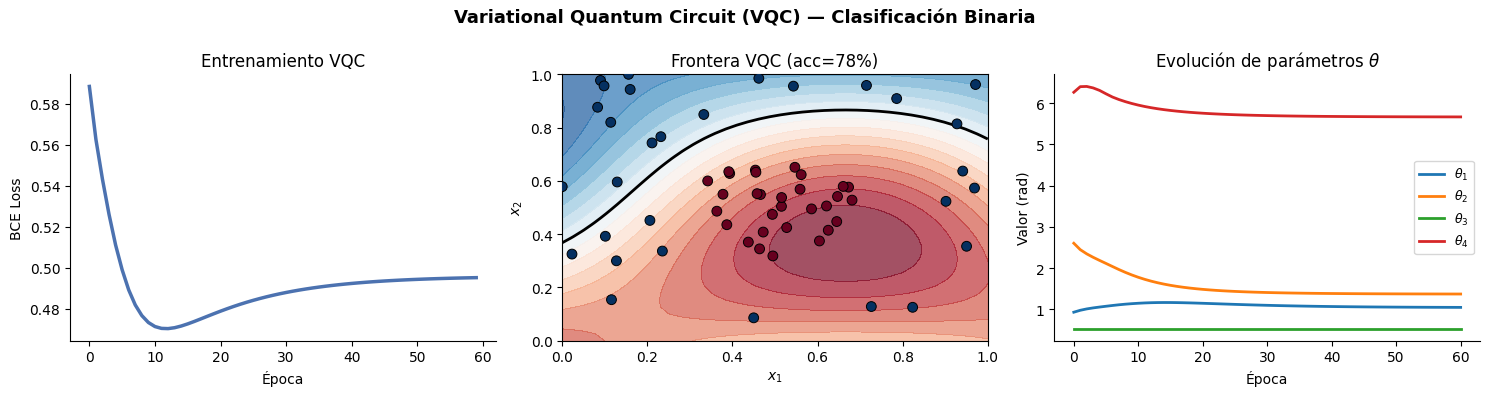

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ── VQC desde cero (sin PennyLane) — clasificación 2D ─────────────────────────

np.random.seed(42)

# ── Simulador cuántico minimal ────────────────────────────────────────────────
def Ry(theta):
    return np.array([[np.cos(theta/2), -np.sin(theta/2)],
                     [np.sin(theta/2),  np.cos(theta/2)]], dtype=complex)

def Rz(theta):
    return np.array([[np.exp(-1j*theta/2), 0],
                     [0, np.exp(1j*theta/2)]], dtype=complex)

def H_gate():
    return np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)

def CNOT_2q():
    return np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)

def apply_1q(state_2q, gate, qubit):
    # state_2q shape (4,)
    if qubit == 0:
        full = np.kron(gate, np.eye(2, dtype=complex))
    else:
        full = np.kron(np.eye(2, dtype=complex), gate)
    return full @ state_2q

def vqc_forward(x, theta):
    # x = [x1, x2], theta = [t1, t2, t3, t4] (4 parametros)
    # 2 qubits
    state = np.array([1,0,0,0], dtype=complex)
    # Codificación de features
    state = apply_1q(state, Ry(x[0]*np.pi), 0)
    state = apply_1q(state, Ry(x[1]*np.pi), 1)
    # Capa variacional 1
    state = apply_1q(state, Ry(theta[0]), 0)
    state = apply_1q(state, Ry(theta[1]), 1)
    state = CNOT_2q() @ state
    # Capa variacional 2
    state = apply_1q(state, Ry(theta[2]), 0)
    state = apply_1q(state, Ry(theta[3]), 1)
    # Medir <Z> en qubit 0
    Z0 = np.array([1,-1,1,-1], dtype=float)  # eigenvalues Z⊗I
    exp_Z0 = np.real(np.conj(state) @ (Z0 * state))
    return (exp_Z0 + 1) / 2   # mapear [-1,1] a [0,1]

def predict_batch(X, theta):
    return np.array([vqc_forward(x, theta) for x in X])

def bce_loss(y_pred, y_true, eps=1e-7):
    y_pred = np.clip(y_pred, eps, 1-eps)
    return -np.mean(y_true * np.log(y_pred) + (1-y_true) * np.log(1-y_pred))

def parameter_shift_grad(X, y, theta, idx, shift=np.pi/2):
    t_plus = theta.copy(); t_plus[idx] += shift
    t_minus = theta.copy(); t_minus[idx] -= shift
    grad = (bce_loss(predict_batch(X, t_plus), y) -
            bce_loss(predict_batch(X, t_minus), y)) / 2.0
    return grad

# ── Dataset: círculos 2D ──────────────────────────────────────────────────────
n = 60
r_inner = 0.35
X_pos = []
while len(X_pos) < n//2:
    p = np.random.uniform(-1, 1, 2)
    if np.linalg.norm(p) < r_inner:
        X_pos.append(p)
X_neg = []
while len(X_neg) < n//2:
    p = np.random.uniform(-1, 1, 2)
    if np.linalg.norm(p) > 0.55 and np.max(np.abs(p)) < 0.95:
        X_neg.append(p)

X = np.array(X_pos + X_neg)
y = np.array([1]*(n//2) + [0]*(n//2), dtype=float)
X = (X - X.min()) / (X.max() - X.min())  # normalizar [0,1]

# ── Entrenamiento VQC ─────────────────────────────────────────────────────────
theta = np.random.uniform(0, 2*np.pi, 4)
lr = 0.4
losses = []
thetas_hist = [theta.copy()]

for epoch in range(60):
    grads = np.array([parameter_shift_grad(X, y, theta, i) for i in range(4)])
    theta -= lr * grads
    loss = bce_loss(predict_batch(X, theta), y)
    losses.append(loss)
    thetas_hist.append(theta.copy())

print(f"Loss final: {losses[-1]:.4f}")
preds = predict_batch(X, theta)
acc = np.mean((preds > 0.5) == y.astype(bool))
print(f"Accuracy: {acc:.2%}")

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) Curva de pérdida
axes[0].plot(losses, color='#4C72B0', linewidth=2.5)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Entrenamiento VQC', fontsize=12)
axes[0].spines[['top','right']].set_visible(False)

# 2) Frontera de decisión final
xx, yy = np.meshgrid(np.linspace(0, 1, 40), np.linspace(0, 1, 40))
X_grid = np.c_[xx.ravel(), yy.ravel()]
Z = predict_batch(X_grid, theta).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
axes[1].contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
scatter = axes[1].scatter(X[:,0], X[:,1], c=y, cmap='RdBu_r', edgecolors='k',
                           linewidth=0.7, s=50, zorder=5)
axes[1].set_title(f'Frontera VQC (acc={acc:.0%})', fontsize=12)
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')

# 3) Evolución de parámetros
for i in range(4):
    vals = [th[i] for th in thetas_hist]
    axes[2].plot(vals, linewidth=2, label=fr'$\theta_{i+1}$')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Valor (rad)')
axes[2].set_title(r'Evolución de parámetros $\theta$', fontsize=12)
axes[2].legend(fontsize=9)
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('Variational Quantum Circuit (VQC) — Clasificación Binaria', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Max-Cut óptimo: 4 aristas cortadas
Particiones óptimas: [[1, 0, 1, 0], [0, 1, 0, 1]]

QAOA óptimo: gamma=0.564, beta=0.322
Valor esperado Max-Cut QAOA: 3.2361 (máximo exacto=4)


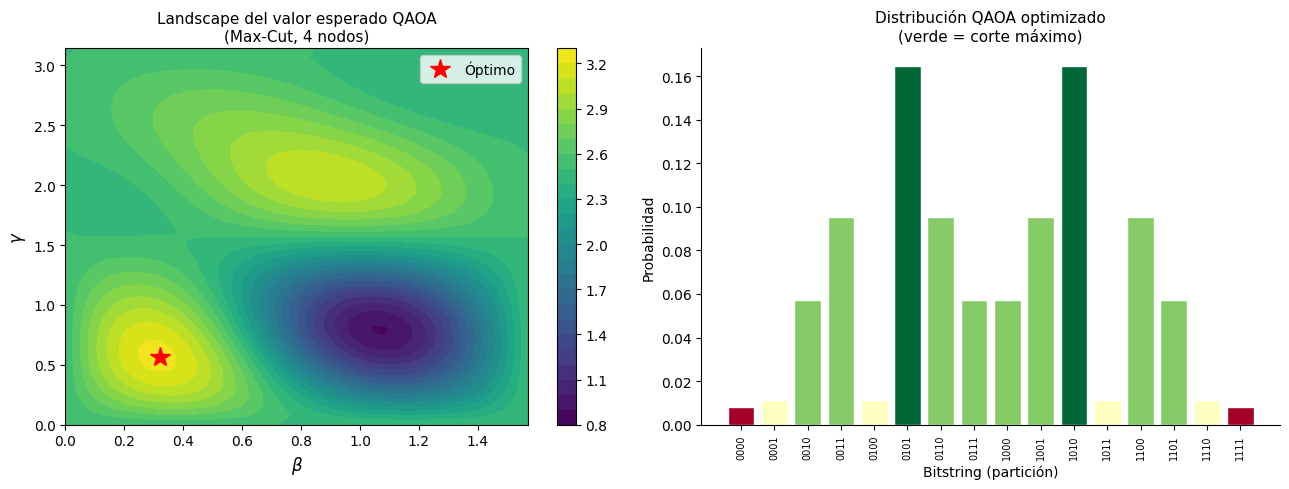

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ── QAOA — Max-Cut en grafo de 4 nodos ────────────────────────────────────────
# Problema Max-Cut: dividir nodos en 2 grupos maximizando aristas cortadas

# Grafo de ejemplo
edges = [(0,1), (0,3), (1,2), (2,3), (1,3)]
n_nodes = 4

def max_cut_value(bitstring, edges):
    return sum(1 for u,v in edges if bitstring[u] != bitstring[v])

# Evaluar todas las posibles particiones (fuerza bruta para comparar)
best_val, best_cut = 0, []
for s in range(2**n_nodes):
    bits = [(s >> i) & 1 for i in range(n_nodes)]
    val = max_cut_value(bits, edges)
    if val > best_val:
        best_val = val
        best_cut = [bits]
    elif val == best_val:
        best_cut.append(bits)

print(f"Max-Cut óptimo: {best_val} aristas cortadas")
print(f"Particiones óptimas: {best_cut}")

# ── Simulación clásica del circuito QAOA (p=1) ────────────────────────────────
def qaoa_circuit(gamma, beta, edges, n):
    # Estado inicial: |+>^n
    psi = np.ones(2**n, dtype=complex) / np.sqrt(2**n)

    # Capa de problema: exp(-i gamma C)
    for u, v in edges:
        for s in range(2**n):
            bu = (s >> u) & 1
            bv = (s >> v) & 1
            if bu != bv:
                psi[s] *= np.exp(-1j * gamma)

    # Capa de mezcla: exp(-i beta B)  B = sum_j X_j
    for q in range(n):
        new_psi = np.zeros_like(psi)
        for s in range(2**n):
            # flip bit q
            s_flip = s ^ (1 << q)
            new_psi[s] += np.cos(beta) * psi[s] - 1j * np.sin(beta) * psi[s_flip]
        psi = new_psi

    return psi

def qaoa_expectation(gamma, beta, edges, n):
    psi = qaoa_circuit(gamma, beta, edges, n)
    probs = np.abs(psi)**2
    # The following line was causing a NameError because 'u' was not defined in this scope.
    # It was also redundant as 'E' calculation below correctly computes the expectation value.
    # exp_C = sum(probs[s] * max_cut_value([(s>>u)&1 for s in [s]],
    #                                       edges) for s in range(2**n)
    #            for _ in [None]
    #            if True)
    # recalcular correctamente
    E = 0
    for s in range(2**n):
        bits = [(s >> i) & 1 for i in range(n)]
        E += probs[s] * max_cut_value(bits, edges)
    return E

# Barrido de parámetros
gammas = np.linspace(0, np.pi, 40)
betas  = np.linspace(0, np.pi/2, 40)
landscape = np.zeros((len(gammas), len(betas)))

for i, g in enumerate(gammas):
    for j, b in enumerate(betas):
        landscape[i, j] = qaoa_expectation(g, b, edges, n_nodes)

best_idx = np.unravel_index(landscape.argmax(), landscape.shape)
g_opt, b_opt = gammas[best_idx[0]], betas[best_idx[1]]
print(f"\nQAOA óptimo: gamma={g_opt:.3f}, beta={b_opt:.3f}")
print(f"Valor esperado Max-Cut QAOA: {landscape.max():.4f} (máximo exacto={best_val})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Landscape
img = axes[0].contourf(betas, gammas, landscape, levels=25, cmap='viridis')
axes[0].plot(b_opt, g_opt, 'r*', markersize=15, label='Óptimo')
axes[0].set_xlabel(r'$\beta$', fontsize=12)
axes[0].set_ylabel(r'$\gamma$', fontsize=12)
axes[0].set_title('Landscape del valor esperado QAOA\n(Max-Cut, 4 nodos)', fontsize=11)
axes[0].legend(fontsize=10)
plt.colorbar(img, ax=axes[0])

# Distribución de probabilidades con parámetros óptimos
psi_opt = qaoa_circuit(g_opt, b_opt, edges, n_nodes)
probs_opt = np.abs(psi_opt)**2
x_labels = [f'{s:04b}' for s in range(16)]
cut_vals  = [max_cut_value([(s>>i)&1 for i in range(n_nodes)], edges) for s in range(16)]
colors_bar = plt.cm.RdYlGn([v/best_val for v in cut_vals])

axes[1].bar(range(16), probs_opt, color=colors_bar, edgecolor='white')
axes[1].set_xticks(range(16))
axes[1].set_xticklabels(x_labels, rotation=90, fontsize=7)
axes[1].set_xlabel('Bitstring (partición)')
axes[1].set_ylabel('Probabilidad')
axes[1].set_title('Distribución QAOA optimizado\n(verde = corte máximo)', fontsize=11)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 7.5 Quantum Neural Network con PennyLane

**PennyLane** es el framework estándar para QML, compatible con PyTorch, JAX y TensorFlow.


In [15]:
# ── PennyLane QNN — código de referencia y guía ──────────────────────────────

try:
    import pennylane as qml
    import pennylane.numpy as pnp
    PL_OK = True
except ImportError:
    PL_OK = False

PENNYLANE_CODE = '''
import pennylane as qml
import pennylane.numpy as np

# ── 1. Definir el dispositivo (simulador) ────────────────────────────────────
dev = qml.device("default.qubit", wires=4)

# ── 2. Feature map (codificación de datos) ───────────────────────────────────
def feature_map(x):
    for i in range(4):
        qml.RY(x[i] * np.pi, wires=i)
    for i in range(3):
        qml.CNOT(wires=[i, i+1])

# ── 3. Ansatz variacional ─────────────────────────────────────────────────────
def ansatz(theta):
    for i in range(4):
        qml.RY(theta[i], wires=i)
        qml.RZ(theta[i+4], wires=i)
    for i in range(3):
        qml.CNOT(wires=[i, i+1])

# ── 4. Circuito QML completo ──────────────────────────────────────────────────
@qml.qnode(dev, interface="autograd")
def vqc(x, theta):
    feature_map(x)
    ansatz(theta)
    return qml.expval(qml.PauliZ(0))

# ── 5. Función de costo y entrenamiento ──────────────────────────────────────
def cost(theta, X, y):
    preds = np.array([vqc(x, theta) for x in X])
    return np.mean((preds - y)**2)

# Optimizar con Adam cuántico
opt = qml.AdamOptimizer(stepsize=0.05)
theta = np.random.uniform(0, 2*np.pi, 8, requires_grad=True)

for step in range(100):
    theta, loss = opt.step_and_cost(lambda t: cost(t, X_train, y_train), theta)
    if step % 10 == 0:
        print(f"Paso {step:3d} | Loss: {loss:.4f}")

# ── 6. Usar hardware IBM Quantum real con PennyLane ───────────────────────────
# pip install pennylane-qiskit
import pennylane as qml

dev_ibm = qml.device(
    "qiskit.ibmq",
    wires=4,
    backend="ibm_brisbane",
    ibmqx_token="TU_TOKEN_AQUI"
)

@qml.qnode(dev_ibm)
def circuit_on_hardware(x, theta):
    feature_map(x)
    ansatz(theta)
    return qml.expval(qml.PauliZ(0))

# ── 7. Quantum Transfer Learning ─────────────────────────────────────────────
# Combinar red neuronal clásica (PyTorch) con capas cuánticas

import torch
import torch.nn as nn

dev = qml.device("default.qubit", wires=4)

@qml.qnode(dev, interface="torch")
def quantum_layer(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(4))
    qml.BasicEntanglerLayers(weights, wires=range(4))
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.classical_pre  = nn.Linear(784, 4)  # e.g., MNIST
        self.q_layer = qml.qnn.TorchLayer(quantum_layer, {"weights": (3, 4)})
        self.classical_post = nn.Linear(4, 10)

    def forward(self, x):
        x = torch.sigmoid(self.classical_pre(x))
        x = self.q_layer(x)
        return self.classical_post(x)
'''

if PL_OK:
    import pennylane as qml
    import pennylane.numpy as pnp
    print("PennyLane disponible:", qml.__version__)

    dev = qml.device("default.qubit", wires=2)

    @qml.qnode(dev)
    def circuit(x, theta):
        qml.RY(x * pnp.pi, wires=0)
        qml.RY(theta[0], wires=0)
        qml.RY(theta[1], wires=1)
        qml.CNOT(wires=[0, 1])
        qml.RY(theta[2], wires=0)
        return qml.expval(qml.PauliZ(0))

    theta = pnp.array([0.5, 1.0, -0.3], requires_grad=True)
    grad_fn = qml.grad(lambda t: circuit(0.4, t))
    grads = grad_fn(theta)
    print(f"Gradientes (parameter shift): {grads}")
    print("\n=== Código de referencia PennyLane completo ===")
    print(PENNYLANE_CODE[:800], "...")
else:
    print("Instala PennyLane: pip install pennylane pennylane-qiskit")
    print("\n=== Código de referencia PennyLane ===")
    print(PENNYLANE_CODE)


Instala PennyLane: pip install pennylane pennylane-qiskit

=== Código de referencia PennyLane ===

import pennylane as qml
import pennylane.numpy as np

# ── 1. Definir el dispositivo (simulador) ────────────────────────────────────
dev = qml.device("default.qubit", wires=4)

# ── 2. Feature map (codificación de datos) ───────────────────────────────────
def feature_map(x):
    for i in range(4):
        qml.RY(x[i] * np.pi, wires=i)
    for i in range(3):
        qml.CNOT(wires=[i, i+1])

# ── 3. Ansatz variacional ─────────────────────────────────────────────────────
def ansatz(theta):
    for i in range(4):
        qml.RY(theta[i], wires=i)
        qml.RZ(theta[i+4], wires=i)
    for i in range(3):
        qml.CNOT(wires=[i, i+1])

# ── 4. Circuito QML completo ──────────────────────────────────────────────────
@qml.qnode(dev, interface="autograd")
def vqc(x, theta):
    feature_map(x)
    ansatz(theta)
    return qml.expval(qml.PauliZ(0))

# ── 5. Función de costo y entrenamiento ─

---
# 8. Estado del Arte del Hardware Cuántico


## 8.1 Principales plataformas de hardware

| Empresa | Tecnología | Qubits (2024) | $T_1$ | $T_2$ | Error por puerta |
|---------|-----------|---------------|-------|-------|-----------------|
| **IBM** | Superconductor (transmon) | 1121 (Condor) | ~100 µs | ~100 µs | ~0.1% (CX) |
| **Google** | Superconductor | 70 (Sycamore) | ~20 µs | ~20 µs | ~0.6% (CZ) |
| **IonQ** | Iones atrapados | 35 (Forte) | >1 hora | >1 hora | ~0.3% (2Q) |
| **Quantinuum** | Iones (H-series) | 56 (H2) | horas | horas | ~0.1% (2Q) |
| **Rigetti** | Superconductor | 84 (Ankaa-3) | ~30 µs | ~20 µs | ~1% (CZ) |
| **Amazon Braket** | Multi-tecnología | acceso nube | — | — | varía |

## 8.2 Era NISQ vs Quantum Fault-Tolerant

```
NISQ (2019-2030?)               Fault-Tolerant (futuro)
─────────────────────────       ──────────────────────────────
• 50-1000 qubits físicos        • Millones de qubits físicos
• Sin corrección de errores     • Código de superficie (surface code)
• Profundidad de circuito <100  • Circuitos arbitrariamente profundos
• VQC, QAOA, QML                • Shor, Grover completo, simulación cuántica
• Ventaja cuántica limitada     • Ventaja cuántica demostrable
```

**Overhead de corrección de errores:** ~1000 qubits físicos por 1 qubit lógico (surface code).
Para factorizar RSA-2048 con Shor: ~4000 qubits lógicos = **~4 millones** de qubits físicos.

## 8.3 Acceso a hardware cuántico real

| Plataforma | Acceso gratuito | Documentación |
|-----------|----------------|---------------|
| IBM Quantum | ✅ (1min/mes uso premium) | https://quantum.ibm.com |
| Amazon Braket | 💲 (pay-per-use) | https://aws.amazon.com/braket |
| Google Quantum AI | Limitado | https://quantumai.google |
| IonQ Cloud | 💲 | https://cloud.ionq.com |
| Azure Quantum | Créditos gratuitos | https://azure.microsoft.com/quantum |


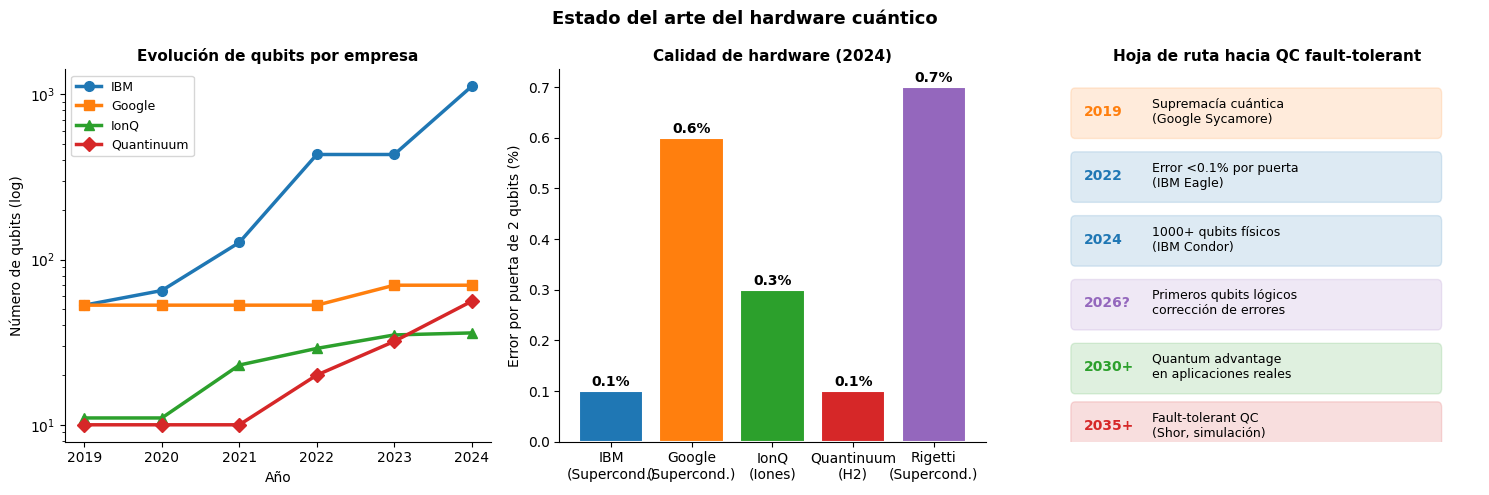

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Comparativa de plataformas cuánticas ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1) Evolución de qubits por empresa
years = [2019, 2020, 2021, 2022, 2023, 2024]
ibm_qubits    = [53, 65, 127, 433, 433, 1121]
google_qubits = [53, 53, 53, 53, 70, 70]
ionq_qubits   = [11, 11, 23, 29, 35, 36]
h_series      = [10, 10, 10, 20, 32, 56]

ax = axes[0]
ax.plot(years, ibm_qubits, 'o-', color='#1F77B4', linewidth=2.5, markersize=7, label='IBM')
ax.plot(years, google_qubits, 's-', color='#FF7F0E', linewidth=2.5, markersize=7, label='Google')
ax.plot(years, ionq_qubits, '^-', color='#2CA02C', linewidth=2.5, markersize=7, label='IonQ')
ax.plot(years, h_series, 'D-', color='#D62728', linewidth=2.5, markersize=7, label='Quantinuum')
ax.set_yscale('log')
ax.set_xlabel('Año')
ax.set_ylabel('Número de qubits (log)')
ax.set_title('Evolución de qubits por empresa', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.set_xticks(years)

# 2) Benchmark de errores por puerta de 2 qubits
platforms = ['IBM\n(Supercond.)', 'Google\n(Supercond.)', 'IonQ\n(Iones)', 'Quantinuum\n(H2)', 'Rigetti\n(Supercond.)']
error_2q = [0.1, 0.6, 0.3, 0.1, 0.7]
colors_err = ['#1F77B4','#FF7F0E','#2CA02C','#D62728','#9467BD']

ax = axes[1]
bars = ax.bar(platforms, error_2q, color=colors_err, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Error por puerta de 2 qubits (%)')
ax.set_title('Calidad de hardware (2024)', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, error_2q):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val}%',
            ha='center', fontsize=10, fontweight='bold')

# 3) Hoja de ruta cuántica (timeline)
ax = axes[2]
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.set_axis_off()
ax.set_title('Hoja de ruta hacia QC fault-tolerant', fontsize=11, fontweight='bold')

timeline = [
    (0.5, 6.2, '2019', 'Supremacía cuántica\n(Google Sycamore)', '#FF7F0E'),
    (0.5, 5.0, '2022', 'Error <0.1% por puerta\n(IBM Eagle)', '#1F77B4'),
    (0.5, 3.8, '2024', '1000+ qubits físicos\n(IBM Condor)', '#1F77B4'),
    (0.5, 2.6, '2026?', 'Primeros qubits lógicos\ncorrección de errores', '#9467BD'),
    (0.5, 1.4, '2030+', 'Quantum advantage\nen aplicaciones reales', '#2CA02C'),
    (0.5, 0.3, '2035+', 'Fault-tolerant QC\n(Shor, simulación)', '#D62728'),
]

for x, y, year, desc, col in timeline:
    ax.add_patch(mpatches.FancyBboxPatch((x, y-0.4), 8.5, 0.75,
                  boxstyle="round,pad=0.1", facecolor=col, alpha=0.15, edgecolor=col))
    ax.text(x+0.2, y, year, fontsize=10, fontweight='bold', color=col, va='center')
    ax.text(x+1.8, y, desc, fontsize=9, va='center', color='black')

plt.suptitle('Estado del arte del hardware cuántico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
# 9. Resumen y Próximos Pasos

## 9.1 Mapa conceptual de la computación cuántica

```
FUNDAMENTOS              HARDWARE                 ALGORITMOS
──────────────           ────────────────         ─────────────────────
Qubit / Bloch sphere     Superconductores         Deutsch-Jozsa (1992)
Superposición            Iones atrapados          Grover O(√N) (1996)
Entrelazamiento          Fotónica                 QFT / Shor (1994)
Notación Dirac           Defectos NV              QPE (1995)
Unitariedad              Topológica               QAOA (2014)
                                                  VQE (2016)
PUERTAS                  PLATAFORMAS              QML
──────────────           ────────────────         ─────────────────────
H, X, Y, Z               IBM Quantum              VQC / Ansatz
S, T, Rx, Ry, Rz         Google Quantum AI        Quantum Kernel / QSVM
CNOT, Toffoli            IonQ / Quantinuum        QNN (PennyLane)
CZ, SWAP                 Amazon Braket            QAOA
                         Azure Quantum            Quantum Transfer Learning
```

## 9.2 Ruta de aprendizaje recomendada

1. **Álgebra lineal cuántica** → Qiskit Textbook (free): https://learning.quantum.ibm.com
2. **Qiskit** → IBM Quantum Learning platform (certificación disponible)
3. **PennyLane** → https://pennylane.ai/qml/ (tutoriales QML)
4. **Libros:** Nielsen & Chuang *"Quantum Computation and Quantum Information"*
5. **Cursos:** MIT 8.370/6.845, Caltech PH/CS 219, Coursera (IBM Quantum)

## 9.3 Dependencias para ejecutar todo el notebook

```bash
# Simulación y algoritmos (sin hardware)
pip install numpy matplotlib scipy

# Hardware IBM Quantum
pip install qiskit qiskit-ibm-runtime qiskit-aer

# Quantum ML
pip install pennylane pennylane-qiskit

# Visualización de circuitos
pip install pylatexenc
```
